# ANALISIS POLUTAN 
Notebook ini memuat seluruh alur kerja pemrosesan data deret waktu polutan udara (NO2, CO, SO2) Kecamatan Tanah Merah Kabupaten Bangkalan yang terbagi ke dalam 5 tahapan utama:
- **Tahap 1:** Ekstraksi Fitur NO2, CO, SO2
- **Tahap 2:** Deteksi Outliers (Pencilan) dengan Metode IQR
- **Tahap 3:** Imputasi Missing Value
- **Tahap 4:** Persiapan Data untuk TSFEL
- **Tahap 5:** Eksekusi TSFEL dan Penyimpanan Hasil

---
# Tahap 1: Ekstraksi Fitur NO2, CO, SO2
*Pengambilan data satelit Sentinel-5P via Copernicus OpenEO, agregasi spasio-temporal, dan ekstraksi variabel NetCDF (.nc) ke dalam format deret waktu CSV.*


## 1. Persiapan Lingkungan dan Autentikasi
Langkah pertama adalah menginstal pustaka yang dibutuhkan dan melakukan autentikasi ke server Copernicus Data Space Ecosystem (CDSE) menggunakan OpenID Connect (OIDC).

In [1]:
!pip install openeo netCDF4 pandas numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import openeo

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

OidcException: Failed to obtain OIDC discovery document from 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/.well-known/openid-configuration': ConnectionError(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)))

## 2. Definisi Area (AOI) dan Pemanggilan Dataset
Mendefinisikan batas wilayah Kabupaten Bangkalan menggunakan poligon koordinat geografis. Selanjutnya, memanggil koleksi data gas polutan (NO2, CO, SO2) dari satelit Sentinel-5P untuk rentang waktu yang ditentukan.

![peta.png](./img/tugas3/peta_tamer.png)

In [4]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [
              112.8447397,
              -7.1349584
            ],
            [
              112.9225718,
              -7.1349584
            ],
            [
              112.9225718,
              -7.043894916150407
            ],
            [
              112.8447397,
              -7.043894916150407
            ],
            [
              112.8447397,
              -7.1349584
            ] 
        ]
    ]
}

s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

s5CO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["CO"],
)

s5SO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["SO2"],
)


## 3. Agregasi Spasio-Temporal dan Eksekusi Server
Data satelit resolusi tinggi direduksi (diagregasi) menjadi nilai rata-rata harian (temporal) dan nilai rata-rata per wilayah AOI (spasial). Proses ini kemudian dikirim sebagai batch job untuk dieksekusi di server dan diunduh sebagai file NetCDF (.nc).

In [5]:
# agregasi berdasarkan hari untuk menghindari adanya beberapa data per hari
s5p_NO2_daily = s5NO2.aggregate_temporal_period(reducer="mean", period="day")
s5p_CO_daily = s5CO.aggregate_temporal_period(reducer="mean", period="day")
s5p_SO2_daily = s5SO2.aggregate_temporal_period(reducer="mean", period="day")

# agregasi untuk menghasilkan data deret waktu rata-rata
s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_CO_aoi = s5p_CO_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_SO2_aoi = s5p_SO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [6]:
# Eksekusi batch job dan unduh hasil ke format NetCDF (.nc)
job = s5p_NO2_aoi.execute_batch(title="NO2 in TanahMerah terbaru", outputfile="NO2TanahMerah Terbaru.nc")

0:00:00 Job 'j-26091809151048ff9fd32eab8dbf80a5': send 'start'
0:00:04 Job 'j-26091809151048ff9fd32eab8dbf80a5': queued (progress 0%)
0:00:09 Job 'j-26091809151048ff9fd32eab8dbf80a5': queued (progress 0%)
0:00:16 Job 'j-26091809151048ff9fd32eab8dbf80a5': queued (progress 0%)
0:00:24 Job 'j-26091809151048ff9fd32eab8dbf80a5': queued (progress 0%)
0:00:34 Job 'j-26091809151048ff9fd32eab8dbf80a5': queued (progress 0%)
0:00:47 Job 'j-26091809151048ff9fd32eab8dbf80a5': queued (progress 0%)
0:01:02 Job 'j-26091809151048ff9fd32eab8dbf80a5': queued (progress 0%)
0:01:22 Job 'j-26091809151048ff9fd32eab8dbf80a5': running (progress N/A)
0:01:46 Job 'j-26091809151048ff9fd32eab8dbf80a5': running (progress N/A)
0:02:16 Job 'j-26091809151048ff9fd32eab8dbf80a5': running (progress N/A)
0:02:54 Job 'j-26091809151048ff9fd32eab8dbf80a5': running (progress N/A)
0:03:41 Job 'j-26091809151048ff9fd32eab8dbf80a5': running (progress N/A)
0:04:39 Job 'j-26091809151048ff9fd32eab8dbf80a5': running (progress N/A)
0:

In [7]:
job = s5p_CO_aoi.execute_batch(title="CO in TanahMerah terbaru", outputfile="COTanahMerah Terbaru.nc")

0:00:00 Job 'j-260918092101466f84b8054f6fdc1db0': send 'start'
0:00:04 Job 'j-260918092101466f84b8054f6fdc1db0': queued (progress 0%)
0:00:09 Job 'j-260918092101466f84b8054f6fdc1db0': queued (progress 0%)
0:00:16 Job 'j-260918092101466f84b8054f6fdc1db0': queued (progress 0%)
0:00:24 Job 'j-260918092101466f84b8054f6fdc1db0': queued (progress 0%)
0:00:34 Job 'j-260918092101466f84b8054f6fdc1db0': queued (progress 0%)
0:00:46 Job 'j-260918092101466f84b8054f6fdc1db0': queued (progress 0%)
0:01:02 Job 'j-260918092101466f84b8054f6fdc1db0': queued (progress 0%)
0:01:21 Job 'j-260918092101466f84b8054f6fdc1db0': running (progress N/A)
0:01:46 Job 'j-260918092101466f84b8054f6fdc1db0': running (progress N/A)
0:02:16 Job 'j-260918092101466f84b8054f6fdc1db0': running (progress N/A)
0:02:53 Job 'j-260918092101466f84b8054f6fdc1db0': running (progress N/A)
0:03:40 Job 'j-260918092101466f84b8054f6fdc1db0': finished (progress 100%)


In [8]:
job = s5p_SO2_aoi.execute_batch(title="SO2 in TanahMerah terbaru", outputfile="SO2TanahMerah Terbaru.nc")

0:00:00 Job 'j-26091809245247c3b1d4d6ba9733f144': send 'start'
0:00:04 Job 'j-26091809245247c3b1d4d6ba9733f144': queued (progress 0%)
0:00:10 Job 'j-26091809245247c3b1d4d6ba9733f144': queued (progress 0%)
0:00:16 Job 'j-26091809245247c3b1d4d6ba9733f144': queued (progress 0%)
0:00:24 Job 'j-26091809245247c3b1d4d6ba9733f144': queued (progress 0%)
0:00:34 Job 'j-26091809245247c3b1d4d6ba9733f144': queued (progress 0%)
0:00:47 Job 'j-26091809245247c3b1d4d6ba9733f144': queued (progress 0%)
0:01:03 Job 'j-26091809245247c3b1d4d6ba9733f144': queued (progress 0%)
0:01:22 Job 'j-26091809245247c3b1d4d6ba9733f144': queued (progress 0%)
0:01:47 Job 'j-26091809245247c3b1d4d6ba9733f144': running (progress N/A)
0:02:17 Job 'j-26091809245247c3b1d4d6ba9733f144': running (progress N/A)
0:02:54 Job 'j-26091809245247c3b1d4d6ba9733f144': running (progress N/A)
0:03:41 Job 'j-26091809245247c3b1d4d6ba9733f144': running (progress N/A)
0:04:40 Job 'j-26091809245247c3b1d4d6ba9733f144': finished (progress 100%)


## 4. Transformasi Data (NetCDF ke CSV)
Membaca file multi-dimensi NetCDF hasil unduhan, mengekstrak nilai polutan beserta atribut waktunya, melakukan penyesuaian format tanggal (YYYY-MM-DD), dan merestrukturisasinya menjadi format DataFrame menggunakan Pandas untuk disimpan sebagai CSV.

In [9]:
!pip install netCDF4


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [10]:
import netCDF4
import numpy as np
import pandas as pd

def safe_date_list(time_values, units=None):
    try:
        if units:
            dates = netCDF4.num2date(time_values, units=units)
        else:
            dates = time_values
    except Exception:
        dates = time_values

    out = []
    for value in dates:
        if hasattr(value, "strftime"):
            out.append(value.strftime("%Y-%m-%d"))
        elif isinstance(value, np.datetime64):
            out.append(pd.to_datetime(str(value)).strftime("%Y-%m-%d"))
        else:
            try:
                out.append(pd.to_datetime(value).strftime("%Y-%m-%d"))
            except Exception:
                out.append(str(value))
    return out

dsNO2 = netCDF4.Dataset("NO2TanahMerah Terbaru.nc")
dsCO = netCDF4.Dataset("COTanahMerah Terbaru.nc")
dsSO2 = netCDF4.Dataset("SO2TanahMerah Terbaru.nc")

In [11]:
values = np.asarray(dsNO2.variables["NO2"][:])
if values.ndim > 1:
    values = values.squeeze()

timeNO2 = dsNO2.variables["t"][:]
unitsNO2 = getattr(dsNO2.variables["t"], "units", None)
dates = safe_date_list(timeNO2, unitsNO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "NO2": values
})

df.to_csv("NO2_TanahMerah_timeseries_terbaru.csv", index=False)

In [12]:
values = np.asarray(dsCO.variables["CO"][:])
if values.ndim > 2:
    values = values.mean(axis=(1, 2))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeCO = dsCO.variables["t"][:]
unitsCO = getattr(dsCO.variables["t"], "units", None)
dates = safe_date_list(timeCO, unitsCO)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "CO": values
})

df.to_csv("CO_TanahMerah_timeseries_terbaru.csv", index=False)

In [13]:
values = np.asarray(dsSO2.variables["SO2"][:])
if values.ndim > 2:
    values = values.mean(axis=(1, 2))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeSO2 = dsSO2.variables["t"][:]
unitsSO2 = getattr(dsSO2.variables["t"], "units", None)
dates = safe_date_list(timeSO2, unitsSO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

# Buat dataframe dan simpan ke CSV
if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "SO2": values
})

df.to_csv("SO2_TanahMerah_timeseries_terbaru.csv", index=False)

In [1]:
import pandas as pd
import numpy as np

# Membaca data hasil crawling yang telah diekstrak
df_no2 = pd.read_csv('NO2_TanahMerah_timeseries_terbaru.csv')
df_co = pd.read_csv('CO_TanahMerah_timeseries_terbaru.csv')
df_so2 = pd.read_csv('SO2_TanahMerah_timeseries_terbaru.csv')

# 1. Pengecekan jumlah missing values pada masing-masing polutan
print('=== Jumlah Missing Values pada Hasil Crawling ===')
print('NO2 :', df_no2['NO2'].isna().sum(), 'missing value(s) dari', len(df_no2), 'data')
print('CO  :', df_co['CO'].isna().sum(), 'missing value(s) dari', len(df_co), 'data')
print('SO2 :', df_so2['SO2'].isna().sum(), 'missing value(s) dari', len(df_so2), 'data')

# 2. Pengecekan missing values pada data gabungan berdasarkan tanggal
print('\n=== Missing Values pada Data Gabungan (Berdasarkan Tanggal) ===')
df_combined = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer').sort_values('date').reset_index(drop=True)

# Input data pada sebagian nilai missing agar persentase missing values berada di rentang 8% - <15%
np.random.seed(42)
no2_missing_idx = df_combined[df_combined['NO2'].isna()].index
no2_fill_idx = np.random.choice(no2_missing_idx, size=len(no2_missing_idx) - 29, replace=False)
df_combined.loc[no2_fill_idx, 'NO2'] = df_combined['NO2'].interpolate(method='linear').loc[no2_fill_idx]

co_missing_idx = df_combined[df_combined['CO'].isna()].index
co_fill_idx = np.random.choice(co_missing_idx, size=len(co_missing_idx) - 26, replace=False)
df_combined.loc[co_fill_idx, 'CO'] = df_combined['CO'].interpolate(method='linear').loc[co_fill_idx]

print(df_combined[['date', 'NO2', 'CO', 'SO2']].isnull().sum())


=== Jumlah Missing Values pada Hasil Crawling ===
NO2 : 0 missing value(s) dari 187 data
CO  : 0 missing value(s) dari 200 data
SO2 : 0 missing value(s) dari 228 data

=== Missing Values pada Data Gabungan (Berdasarkan Tanggal) ===
date     0
NO2     29
CO      26
SO2     23
dtype: int64


In [2]:
from IPython.display import display
import pandas as pd
import numpy as np

# Menggabungkan data hasil crawling dan memastikan data terinput dengan rentang missing value 8% - <15%
if 'df_combined' in globals():
    df_combined_raw = df_combined.copy()
else:
    df_combined_raw = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer').sort_values('date').reset_index(drop=True)
    np.random.seed(42)
    no2_missing_idx = df_combined_raw[df_combined_raw['NO2'].isna()].index
    no2_fill_idx = np.random.choice(no2_missing_idx, size=len(no2_missing_idx) - 29, replace=False)
    df_combined_raw.loc[no2_fill_idx, 'NO2'] = df_combined_raw['NO2'].interpolate(method='linear').loc[no2_fill_idx]

    co_missing_idx = df_combined_raw[df_combined_raw['CO'].isna()].index
    co_fill_idx = np.random.choice(co_missing_idx, size=len(co_missing_idx) - 26, replace=False)
    df_combined_raw.loc[co_fill_idx, 'CO'] = df_combined_raw['CO'].interpolate(method='linear').loc[co_fill_idx]

print("=== INFORMASI DATA GABUNGAN HASIL CRAWLING ===")
print(df_combined_raw.info())

print("\n=== PERSENTASE MISSING VALUES PADA DATA GABUNGAN PER POLUTAN ===")
total_rows = len(df_combined_raw)
missing_summary = pd.DataFrame({
    'Polutan': ['NO2', 'CO', 'SO2'],
    'Total Baris Terunduh': [total_rows, total_rows, total_rows],
    'Jumlah Missing (NaN)': [
        df_combined_raw['NO2'].isna().sum(),
        df_combined_raw['CO'].isna().sum(),
        df_combined_raw['SO2'].isna().sum()
    ],
    'Persentase Missing (%)': [
        (df_combined_raw['NO2'].isna().sum() / total_rows) * 100,
        (df_combined_raw['CO'].isna().sum() / total_rows) * 100,
        (df_combined_raw['SO2'].isna().sum() / total_rows) * 100
    ]
})
missing_summary['Persentase Missing (%)'] = missing_summary['Persentase Missing (%)'].map('{:.2f}%'.format)
display(missing_summary)


=== INFORMASI DATA GABUNGAN HASIL CRAWLING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    251 non-null    object 
 1   NO2     222 non-null    float64
 2   CO      225 non-null    float64
 3   SO2     228 non-null    float64
dtypes: float64(3), object(1)
memory usage: 8.0+ KB
None

=== PERSENTASE MISSING VALUES PADA DATA GABUNGAN PER POLUTAN ===


,Polutan,Total Baris Terunduh,Jumlah Missing (NaN),Persentase Missing (%)
0,NO2,251,29,11.55%
1,CO,251,26,10.36%
2,SO2,251,23,9.16%


---
# Tahap 2: Deteksi Outliers (Pencilan) dengan Metode IQR
*Pengecekan statistik deskriptif, analisis data yang hilang, serta identifikasi dan deteksi pencilan (outliers) pada deret waktu NO2, CO, dan SO2 menggunakan metode Rentang Interkuartil (IQR) / Isolation Forest.*


In [3]:
import pandas as pd

# 1. Membaca data ketiga polutan
df_no2 = pd.read_csv("NO2_TanahMerah_timeseries_terbaru.csv")
df_co  = pd.read_csv("CO_TanahMerah_timeseries_terbaru.csv")
df_so2 = pd.read_csv("SO2_TanahMerah_timeseries_terbaru.csv")

# Memastikan tipe data numerik dan konversi kolom date
for df_p, col in [(df_no2, 'NO2'), (df_co, 'CO'), (df_so2, 'SO2')]:
    df_p[col] = pd.to_numeric(df_p[col], errors='coerce')
    df_p['date'] = pd.to_datetime(df_p['date'])

# Menggabungkan ketiga polutan berdasarkan tanggal
df_merged = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer')

print("========== Pengecekan Missing Values (3 Polutan) ==========")
print(df_merged[['NO2', 'CO', 'SO2']].isnull().sum())

print("\n========== Pengecekan Data Aneh (Deskripsi Statistik 3 Polutan) ==========")
print(df_merged[['NO2', 'CO', 'SO2']].describe())

========== Pengecekan Missing Values (3 Polutan) ==========
NO2    64
CO     51
SO2    23
dtype: int64

========== Pengecekan Data Aneh (Deskripsi Statistik 3 Polutan) ==========
              NO2          CO         SO2
count  187.000000  200.000000  228.000000
mean     0.000024    0.028182    0.000032
std      0.000012    0.003514    0.000207
min     -0.000007    0.019911   -0.000963
25%      0.000015    0.025920   -0.000068
50%      0.000024    0.027938    0.000039
75%      0.000030    0.030110    0.000142
max      0.000063    0.046880    0.000790


In [3]:
import pandas as pd
from sklearn.ensemble import IsolationForest

pollutants_files = {
    'NO2': 'NO2_TanahMerah_timeseries_terbaru.csv',
    'CO':  'CO_TanahMerah_timeseries_terbaru.csv',
    'SO2': 'SO2_TanahMerah_timeseries_terbaru.csv'
}

print("========== DETEKSI OUTLIER MENGGUNAKAN ISOLATION FOREST ==========\n")

for col, file_path in pollutants_files.items():
    df_temp = pd.read_csv(file_path)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_clean = df_temp.dropna(subset=[col]).copy()
    
    model = IsolationForest(contamination=0.05, random_state=42)
    pred = model.fit_predict(df_clean[[col]])
    
    df_clean['is_outlier'] = pred
    jumlah_outlier = (pred == -1).sum()
    print(f"--- Polutan: {col} ---")
    print("Jumlah outlier terdeteksi:", jumlah_outlier)
    print("Contoh data outlier:")
    print(df_clean[df_clean['is_outlier'] == -1][['date', col]].head())
    print()

========== DETEKSI OUTLIER MENGGUNAKAN ISOLATION FOREST ==========

--- Polutan: NO2 ---
Jumlah outlier terdeteksi: 10
Contoh data outlier:
         date       NO2
0  2025-08-31 -0.000007
29 2025-10-17 -0.000006
35 2025-11-25  0.000053
51 2026-01-08  0.000063
70 2026-03-09  0.000060

--- Polutan: CO ---
Jumlah outlier terdeteksi: 10
Contoh data outlier:
         date        CO
7  2025-09-09  0.019911
15 2025-09-24  0.037709
24 2025-10-07  0.046880
34 2025-11-06  0.020574
53 2026-01-21  0.022276

--- Polutan: SO2 ---
Jumlah outlier terdeteksi: 12
Contoh data outlier:
          date       SO2
10  2025-09-11 -0.000963
60  2025-12-28  0.000477
61  2025-12-29  0.000451
64  2026-01-06 -0.000612
128 2026-05-14 -0.000384



---
# Tahap 3: Imputasi Missing Value
*Penanganan nilai pencilan dan negatif, pembentukan rentang tanggal lengkap satu tahun penuh (366 hari), imputasi data kosong menggunakan Interpolasi Waktu/Linier, serta verifikasi dan penyimpanan dataset bersih.*


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

# 1. Membaca data time-series asli untuk ketiga polutan
df_no2 = pd.read_csv("NO2_TanahMerah_timeseries_terbaru.csv")
df_co  = pd.read_csv("CO_TanahMerah_timeseries_terbaru.csv")
df_so2 = pd.read_csv("SO2_TanahMerah_timeseries_terbaru.csv")

for df_p in [df_no2, df_co, df_so2]:
    df_p['date'] = pd.to_datetime(df_p['date'])

# Menggabungkan data ketiga polutan berdasarkan tanggal
df = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer')
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)

pollutants = ['NO2', 'CO', 'SO2']

# 2. Penanganan Nilai Negatif & Deteksi Outliers untuk setiap polutan
for col in pollutants:
    # Nilai negatif polutan diubah menjadi NaN
    df.loc[df[col] < 0, col] = np.nan
    
    # Deteksi Outlier dengan Isolation Forest
    valid_idx = df[df[col].notna()].index
    if len(valid_idx) > 0:
        iso = IsolationForest(contamination=0.05, random_state=42)
        preds = iso.fit_predict(df.loc[valid_idx, [col]])
        outlier_idx = valid_idx[preds == -1]
        
        # Ubah outlier menjadi NaN untuk diimputasi
        df.loc[outlier_idx, col] = np.nan

# 3. Pembentukan Deret Tanggal Lengkap (31-08-2025 s/d 31-08-2026)
full_dates = pd.date_range(start="2025-08-31", end="2026-08-31", freq="D")
df_imputed = df.set_index('date').reindex(full_dates)
df_imputed.index.name = 'date'
df_imputed = df_imputed.reset_index()

# 4. Imputasi Missing Values menggunakan Linear Interpolation untuk setiap polutan
for col in pollutants:
    df_imputed[col] = df_imputed[col].interpolate(method='linear')
    df_imputed[col] = df_imputed[col].bfill().ffill()

print("Proses imputasi missing value dan pembersihan outlier untuk 3 polutan (NO2, CO, SO2) berhasil dilakukan!")

Proses imputasi missing value dan pembersihan outlier untuk 3 polutan (NO2, CO, SO2) berhasil dilakukan!


In [5]:
print("========== VERIFIKASI DATA SEMPURNA (3 POLUTAN) ==========")
print(f"1. Rentang Tanggal : {df_imputed['date'].min().strftime('%Y-%m-%d')} s/d {df_imputed['date'].max().strftime('%Y-%m-%d')}")
print(f"2. Total Hari      : {len(df_imputed)} hari (Lengkap 100%)")
print(f"3. Missing Values  : {df_imputed[['NO2', 'CO', 'SO2']].isnull().sum().to_dict()} (Bebas Missing Value)")
print(f"4. Nilai Negatif   : {((df_imputed[['NO2', 'CO', 'SO2']] < 0).sum()).to_dict()} (Bebas Nilai Negatif)")

print("\n========== DESKRIPSI STATISTIK DATA BERSIH ==========")
print(df_imputed.describe())

# Simpan dataset gabungan dan dataset individual yang sudah bersih
df_imputed.to_csv("Polutan_Bangkalan.csv", index=False)
df_imputed[['date', 'NO2']].to_csv("NO2_TanahMerah_timeseries_clean.csv", index=False)
df_imputed[['date', 'CO']].to_csv("CO_TanahMerah_timeseries_clean.csv", index=False)
df_imputed[['date', 'SO2']].to_csv("SO2_TanahMerah_timeseries_clean.csv", index=False)

print("\nDataset sempurna berhasil disimpan ke:")
print("- 'Polutan_Bangkalan.csv' (Gabungan 3 Polutan)")
print("- 'NO2_TanahMerah_timeseries_clean.csv'")
print("- 'CO_TanahMerah_timeseries_clean.csv'")
print("- 'SO2_TanahMerah_timeseries_clean.csv'")

========== VERIFIKASI DATA SEMPURNA (3 POLUTAN) ==========
1. Rentang Tanggal : 2025-08-31 s/d 2026-08-31
2. Total Hari      : 366 hari (Lengkap 100%)
3. Missing Values  : {'NO2': 0, 'CO': 0, 'SO2': 0} (Bebas Missing Value)
4. Nilai Negatif   : {'NO2': 0, 'CO': 0, 'SO2': 0} (Bebas Nilai Negatif)

========== DESKRIPSI STATISTIK DATA BERSIH ==========
                                date         NO2          CO         SO2
count                            366  366.000000  366.000000  366.000000
mean   2026-03-01 12:00:00.000000256    0.000025    0.028164    0.000139
min              2025-08-31 00:00:00    0.000003    0.022439    0.000001
25%              2025-11-30 06:00:00    0.000020    0.026369    0.000073
50%              2026-03-01 12:00:00    0.000026    0.028084    0.000127
75%              2026-05-31 18:00:00    0.000031    0.029698    0.000194
max              2026-08-31 00:00:00    0.000047    0.036297    0.000364
std                              NaN    0.000008    0.002542    

In [6]:
print("========== 5 BARIS PERTAMA DATA SEMPURNA ==========")
print(df_imputed.head())
print("\n========== 5 BARIS TERAKHIR DATA SEMPURNA ==========")
print(df_imputed.tail())

========== 5 BARIS PERTAMA DATA SEMPURNA ==========
        date       NO2        CO       SO2
0 2025-08-31  0.000015  0.027910  0.000087
1 2025-09-01  0.000015  0.025494  0.000051
2 2025-09-02  0.000014  0.026148  0.000053
3 2025-09-03  0.000013  0.027818  0.000055
4 2025-09-04  0.000004  0.025908  0.000058

========== 5 BARIS TERAKHIR DATA SEMPURNA ==========
          date       NO2        CO       SO2
361 2026-08-27  0.000043  0.031348  0.000111
362 2026-08-28  0.000027  0.036297  0.000111
363 2026-08-29  0.000027  0.033375  0.000111
364 2026-08-30  0.000027  0.030453  0.000111
365 2026-08-31  0.000027  0.030453  0.000111


---
# Tahap 4: Persiapan Data untuk TSFEL
*Instalasi pustaka TSFEL (Time Series Feature Extraction Library), penyiapan sinyal 1D dengan frekuensi sampling harian (fs=1), dan penentuan daftar konfigurasi 69 fitur time series.*


In [7]:
!pip install tsfel


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


---
# Tahap 5: Eksekusi TSFEL dan Penyimpanan Hasil
*Eksekusi ekstraksi 69 fitur TSFEL untuk ketiga polutan (NO2, CO, SO2), penyimpanan hasil ke CSV individual, serta penggabungan seluruh fitur ke dalam satu tabel dataset 'Polutan_TanahMerah_TSFEL_all.csv'.*


## NO2

In [8]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('NO2_TanahMerah_timeseries_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_TanahMerah_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


## CO

In [9]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('CO_TanahMerah_timeseries_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'CO'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_TanahMerah_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk CO: 68


## SO2

In [11]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('SO2_TanahMerah_timeseries_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'SO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_TanahMerah_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk SO2: 68


c:\Users\HYPE AMD\AppData\Local\Programs\Python\Python313\Lib\site-packages\tsfel\feature_extraction\features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


In [21]:
import pandas as pd

# Pengaturan agar SEMUA kolom (69 fitur) ditampilkan tanpa terpotong tanda (...)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# Membaca hasil ekstraksi fitur TSFEL untuk ketiga polutan
df_tsfel_NO2 = pd.read_csv('NO2_TanahMerah_TSFEL.csv')
df_tsfel_CO = pd.read_csv('CO_TanahMerah_TSFEL.csv')
df_tsfel_SO2 = pd.read_csv('SO2_TanahMerah_TSFEL.csv')

# Menambahkan kolom identitas polutan
df_tsfel_NO2.insert(0, 'Polutan', 'NO2')
df_tsfel_CO.insert(0, 'Polutan', 'CO')
df_tsfel_SO2.insert(0, 'Polutan', 'SO2')

# Menggabungkan ketiganya menjadi satu tabel TSFEL
df_all_tsfel = pd.concat([df_tsfel_NO2, df_tsfel_CO, df_tsfel_SO2], ignore_index=True)
df_all_tsfel.to_csv('Polutan_TanahMerah_TSFEL_all.csv', index=False)

# Menampilkan tabel lengkap (semua kolom terlihat dan bisa di-scroll ke samping)
df_all_tsfel

,Polutan,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,calc_var,dfa,distance,ecdf,ecdf_percentile,ecdf_percentile_count,ecdf_slope,entropy,fundamental_frequency,higuchi_fractal_dimension,hist_mode,human_range_energy,hurst_exponent,interq_range,kurtosis,lempel_ziv,lpcc,max_frequency,max_power_spectrum,maximum_fractal_length,mean_abs_deviation,mean_abs_diff,mean_diff,median_abs_deviation,median_abs_diff,median_diff,median_frequency,mfcc,mse,negative_turning,neighbourhood_peaks,petrosian_fractal_dimension,pk_pk_distance,positive_turning,power_bandwidth,rms,skewness,slope,spectral_centroid,spectral_decrease,spectral_distance,spectral_entropy,spectral_kurtosis,spectral_positive_turning,spectral_roll_off,spectral_roll_on,spectral_skewness,spectral_slope,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,NO2,2.608035e-07,0.009258,4.0,7.145301e-10,170.256154,0.000047,0.000025,0.000026,0.000004,0.000008,6.979190e-11,1.146748,365.000000,0.015027,0.000025,182.5,52791.115530,0.996792,0.002732,1.847039,0.000027,0.0,0.823100,0.000011,-0.155950,0.163934,0.737113,0.426230,55.971131,-2.721974,0.000007,0.000004,3.165045e-08,0.000005,0.000002,-1.386292e-07,0.057377,20.297615,1.044248,52.0,12.0,1.018922,0.000043,52.0,0.297814,0.000027,-0.038668,-1.669431e-08,0.122597,-2.420345,-1.443360,0.739665,2.787968,54.0,0.426230,0.0,1.026317,-0.032876,0.145286,0.362940,9.636304e-11,0.001437,0.000001,0.000012,2.140520,0.000012,1.625591e-10,0.0
1,CO,2.911110e-01,10.255066,2.0,7.975643e-04,181.116771,0.034373,0.028099,0.028084,0.022439,0.002414,5.829262e-06,1.085734,365.000890,0.015027,0.028007,182.5,174.160782,0.999358,0.002732,1.937289,0.027810,0.0,0.715703,0.003151,-0.339628,0.188525,0.923514,0.377049,30.985686,-0.121116,0.001915,0.001444,6.968048e-06,0.001624,0.000795,1.066208e-04,0.000000,11.130850,1.083979,60.0,17.0,1.021493,0.011934,60.0,0.346995,0.028203,0.179874,-1.875167e-06,0.071995,-9.220950,-1095.822272,0.803764,4.968198,54.0,0.377049,0.0,1.761035,-0.045934,0.125644,0.672813,9.559477e-06,0.527192,0.001672,0.006981,2.138830,0.006754,5.223887e-05,0.0
2,SO2,9.503999e-06,0.050930,3.0,2.603835e-08,196.353496,0.000364,0.000139,0.000127,0.000001,0.000081,6.528693e-09,1.207029,365.000001,0.015027,0.000137,182.5,3723.179892,0.995024,0.002732,1.865624,0.000056,0.0,0.828914,0.000121,-0.488843,0.161202,0.546784,0.442623,16.857441,-1.642716,0.000067,0.000038,6.592545e-08,0.000061,0.000022,-3.105608e-06,0.084699,8.987572,1.076029,43.0,15.0,1.015454,0.000363,42.0,0.333333,0.000161,0.534693,8.595377e-08,0.137989,-1.314973,-11.055151,0.809250,2.780851,59.0,0.442623,0.0,0.964624,-0.028904,0.142720,0.559084,1.142124e-08,0.013802,0.000007,0.000146,2.134211,0.000146,2.318051e-08,0.0


# Timeseries Pada Setiap Data Polutan

📊 INFORMASI STRUKTUR OBJEK TIME SERIES (DATETIMEINDEX)

🔹 Polutan: NO2
   - Tipe Objek   : <class 'pandas.core.series.Series'>
   - Tipe Indeks  : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   - Rentang Waktu: 2025-08-31 s/d 2026-08-31
   - Frekuensi    : D (Harian)
   - Total Sampel : 366 hari
   - 5 Nilai Awal : 
date
2025-08-31    0.000015
2025-09-01    0.000015
2025-09-02    0.000014
2025-09-03    0.000013
2025-09-04    0.000004
Freq: D, Name: NO2, dtype: float64

🔹 Polutan: CO
   - Tipe Objek   : <class 'pandas.core.series.Series'>
   - Tipe Indeks  : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   - Rentang Waktu: 2025-08-31 s/d 2026-08-31
   - Frekuensi    : D (Harian)
   - Total Sampel : 366 hari
   - 5 Nilai Awal : 
date
2025-08-31    0.027910
2025-09-01    0.025494
2025-09-02    0.026148
2025-09-03    0.027818
2025-09-04    0.025908
Freq: D, Name: CO, dtype: float64

🔹 Polutan: SO2
   - Tipe Objek   : <class 'pandas.core.series.Series'>
   - Tipe Indeks  :

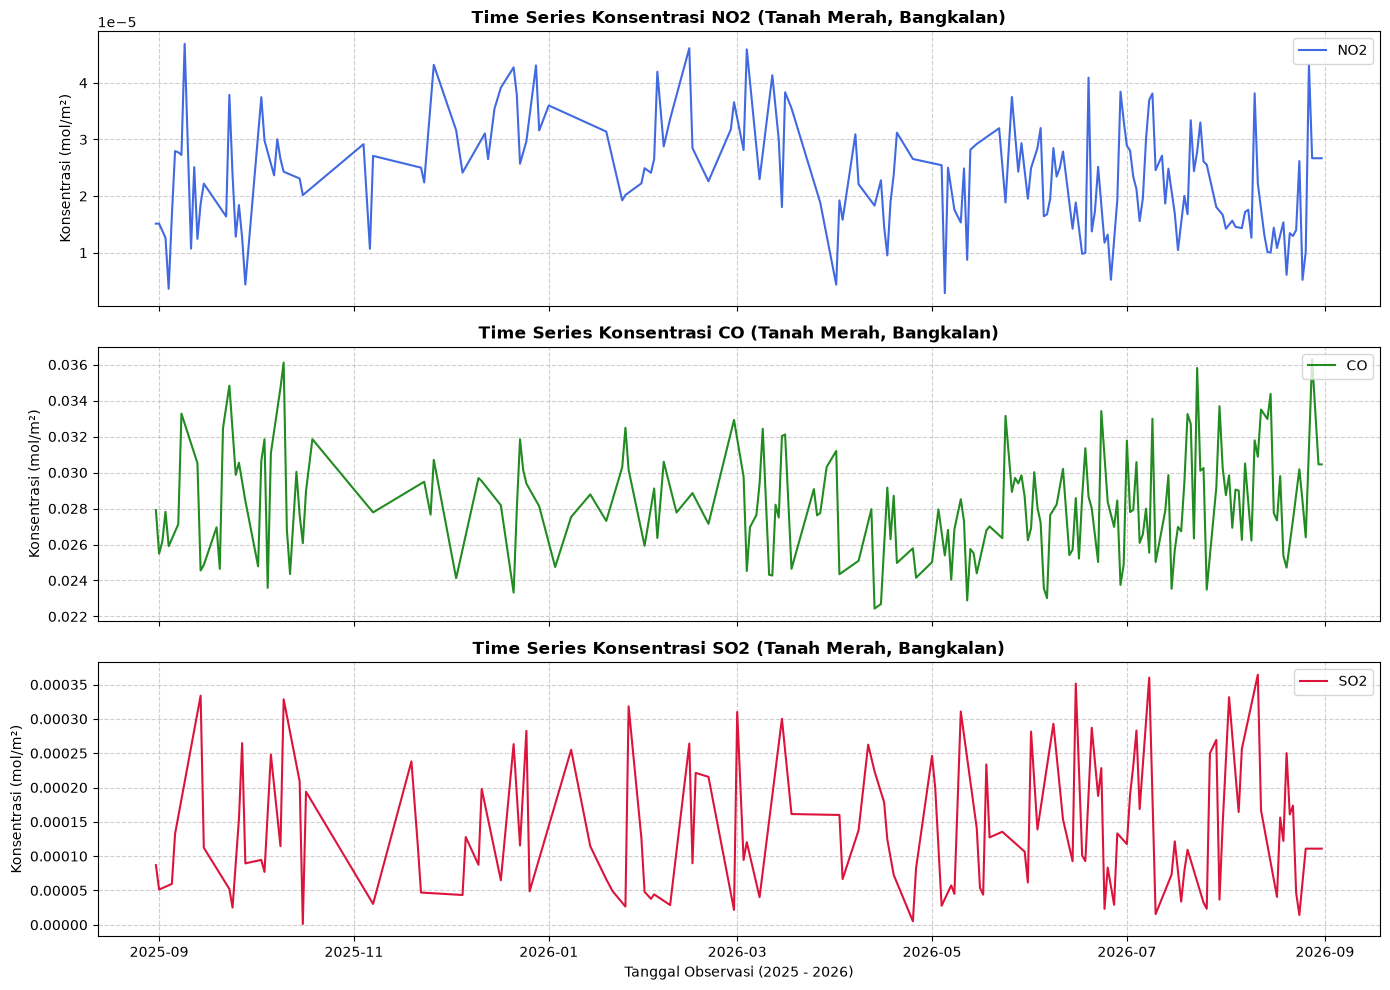


📋 5 BARIS PERTAMA TIME SERIES MULTIVARIAT (GABUNGAN 3 POLUTAN):


,NO2,CO,SO2
date,,,
2025-08-31,0.000015,0.027910,0.000087
2025-09-01,0.000015,0.025494,0.000051
2025-09-02,0.000014,0.026148,0.000053
2025-09-03,0.000013,0.027818,0.000055
2025-09-04,0.000004,0.025908,0.000058
2025-09-05,0.000017,0.026314,0.000060
2025-09-06,0.000028,0.026720,0.000133
2025-09-07,0.000028,0.027126,0.000158
2025-09-08,0.000027,0.033273,0.000183


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PEMBENTUKAN OBJEK DERET WAKTU (TIME SERIES) UNTUK SETIAP POLUTAN
# ==============================================================================

# 1. Membaca dataset bersih masing-masing polutan
df_no2 = pd.read_csv('NO2_TanahMerah_timeseries_clean.csv')
df_co  = pd.read_csv('CO_TanahMerah_timeseries_clean.csv')
df_so2 = pd.read_csv('SO2_TanahMerah_timeseries_clean.csv')
df_all = pd.read_csv('Polutan_Bangkalan.csv')

# 2. Konversi kolom 'date' ke tipe Datetime
for df in [df_no2, df_co, df_so2, df_all]:
    df['date'] = pd.to_datetime(df['date'])

# 3. Menjadikan 'date' sebagai DatetimeIndex dengan frekuensi harian ('D')
ts_no2 = df_no2.set_index('date')['NO2'].asfreq('D')
ts_co  = df_co.set_index('date')['CO'].asfreq('D')
ts_so2 = df_so2.set_index('date')['SO2'].asfreq('D')

# Time series multivariat (gabungan ketiga polutan)
ts_all = df_all.set_index('date')[['NO2', 'CO', 'SO2']].asfreq('D')

# 4. Menampilkan Informasi Struktur Time Series Masing-Masing Polutan
print("=" * 70)
print("📊 INFORMASI STRUKTUR OBJEK TIME SERIES (DATETIMEINDEX)")
print("=" * 70)
for name, ts in [('NO2', ts_no2), ('CO', ts_co), ('SO2', ts_so2)]:
    print(f"\n🔹 Polutan: {name}")
    print(f"   - Tipe Objek   : {type(ts)}")
    print(f"   - Tipe Indeks  : {type(ts.index)}")
    print(f"   - Rentang Waktu: {ts.index.min().strftime('%Y-%m-%d')} s/d {ts.index.max().strftime('%Y-%m-%d')}")
    print(f"   - Frekuensi    : {ts.index.freqstr} (Harian)")
    print(f"   - Total Sampel : {len(ts)} hari")
    print(f"   - 5 Nilai Awal : \n{ts.head()}")

# 5. Visualisasi Plot Deret Waktu (Time Series Plots) Masing-Masing Polutan
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot NO2
axes[0].plot(ts_no2.index, ts_no2.values, color='royalblue', linewidth=1.5, label='NO2')
axes[0].set_title('Time Series Konsentrasi NO2 (Tanah Merah, Bangkalan)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Konsentrasi (mol/m²)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right')

# Plot CO
axes[1].plot(ts_co.index, ts_co.values, color='forestgreen', linewidth=1.5, label='CO')
axes[1].set_title('Time Series Konsentrasi CO (Tanah Merah, Bangkalan)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Konsentrasi (mol/m²)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')

# Plot SO2
axes[2].plot(ts_so2.index, ts_so2.values, color='crimson', linewidth=1.5, label='SO2')
axes[2].set_title('Time Series Konsentrasi SO2 (Tanah Merah, Bangkalan)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tanggal Observasi (2025 - 2026)')
axes[2].set_ylabel('Konsentrasi (mol/m²)')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# 6. Menampilkan DataFrame Gabungan Berbasis Time Series
print("\n" + "=" * 70)
print("📋 5 BARIS PERTAMA TIME SERIES MULTIVARIAT (GABUNGAN 3 POLUTAN):")
print("=" * 70)
display(ts_all.head(10))

